In [1]:
!pip install mne
import torch 
import kagglehub
import pandas as pd
import numpy as np
import mne  
import os
import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
from scipy.stats import zscore
from scipy.signal import welch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 120.2 MB/s eta 0:00:0000:01
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [2]:
print("Verificando dataset...")
path = kagglehub.dataset_download("sigfest/database-for-emotion-recognition-system-gameemo")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando usando: {device}")
    

Verificando dataset...


100%|██████████| 1.70G/1.70G [01:59<00:00, 15.3MB/s]

Extracting files...


Treinando usando: cuda


In [3]:
def convert_csv_to_fif(pasta_base_dataset, pasta_destino_fif):
    os.makedirs(pasta_destino_fif, exist_ok=True)
    padrao_busca = os.path.join(pasta_base_dataset, "GAMEEMO", "*", "Raw EEG Data", ".csv format", "*.csv")
    todos_arquivos = glob.glob(padrao_busca, recursive=True)
    canais_oficiais = ['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'O1', 'O2', 'P7', 'P8', 'T7', 'T8'] #apenas os eletrodos do cerebro

    for arquivo in todos_arquivos:
        nome_original = os.path.basename(arquivo)
        testado = nome_original[:3] 
        jogo = nome_original[3:5]

        print(f"Processando: Sujeito {testado} | Jogo {jogo}")

        df = pd.read_csv(arquivo)
        df_limpo = df[canais_oficiais] 
        nomes_canais = list(df_limpo.columns)
        df_volts = df_limpo.T * 1e-6 #converte de microvolts para volts
        taxa_amostragem=128 #taxa de frequencia utilizada pelo aparelho de EEG

        info = mne.create_info(ch_names=nomes_canais, sfreq=taxa_amostragem, ch_types='eeg') #explicita que os canais sao EEG, que a frequencia é 128 e os nomes das colunas
        info.set_montage('standard_1020') #mapeia no cérebro onde fica cada eletrodo
        raw = mne.io.RawArray(df_volts, info) #objeto que vai guardar a planilha do pandas e um dicionario com as informações pertinentes 

        nome_arquivo_saida = f"{testado}_{jogo}_raw.fif" 
        caminho_salvamento = os.path.join(pasta_destino_fif, nome_arquivo_saida)
        raw.save(caminho_salvamento, overwrite=True, verbose=False)
        print(f"✅ Salvo com sucesso em: {caminho_salvamento}\n")
        print("\nObjeto MNE criado com sucesso!")

    print(f"✅ Conversão concluída! {len(todos_arquivos)} arquivos CSV transformados em objetos MNE (.fif).")

In [4]:
#filtra as frequencias com base nas frequencias cerebrais
def aplicar_filtro(raw, l_freq=0.5, h_freq=45.0):   
    raw_filtrado = raw.copy()
    raw_filtrado.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin', verbose=False)
    return raw_filtrado

#cria janelas com sobreposicao de 1seg para resolver o problema de borda e aumenta o tamanho do dataset pra treinar o modelo
def overlap(raw):
    return mne.make_fixed_length_epochs(raw,duration=1.0,overlap=0.5,verbose=False)

#normaliza os valores para todos os eletrodos para a mesma escala padrão e impede a enganação por valores outliers
def normalize_epochs(epochs_data):
    epochs_norm = zscore(epochs_data, axis=2) 
    epochs_norm = np.nan_to_num(epochs_norm) 
    return epochs_norm

#cria a pipeline de processamento corretamente 
def process_eeg_pipeline(pasta_origem, pasta_destino):
    os.makedirs(pasta_destino, exist_ok=True)
    arquivos = glob.glob(os.path.join(pasta_origem, "*.fif"))
    
    for caminho_arquivo in arquivos:
        nome_original = os.path.basename(caminho_arquivo)
        testado, jogo, _ = nome_original.split("_")
        
        raw = mne.io.read_raw_fif(caminho_arquivo, preload=True, verbose=False) #retira o arquivo do disco e coloca na RAM para processar
        raw_filtrado = aplicar_filtro(raw) 
        epochs = overlap(raw_filtrado)

        matriz_3d = epochs.get_data() #converte para uma matriz 3d (n_segundos, n_canais, nfotos_por_segundo)
        matriz_3d_normalizada = normalize_epochs(matriz_3d)
        
        nome_arquivo_saida = f"{testado}_{jogo}_tensor.npy"
        caminho_numpy = os.path.join(pasta_destino, nome_arquivo_saida)
        np.save(caminho_numpy, matriz_3d_normalizada)
        
    print(f"✅ Pipeline modular concluído! {len(arquivos)} arquivos processados e normalizados.")


if __name__ == "__main__":
    pasta_intermediaria_fif = "./data/processed/mne_raw"
    pasta_final_numpy = "./data/processed/numpy"

    print("🚀 Iniciando a Construção da Base de Dados de EEG...")
    #path foi pego na ultima célula
    print("\n--- FASE 1: Extraindo arquivos CSV ---")
    convert_csv_to_fif(path, pasta_intermediaria_fif)
    
    print("\n--- FASE 2: Aplicando Filtros, Janelas e Normalização ---")
    process_eeg_pipeline(pasta_intermediaria_fif, pasta_final_numpy)

🚀 Iniciando a Construção da Base de Dados de EEG...

--- FASE 1: Extraindo arquivos CSV ---
Processando: Sujeito S09 | Jogo G3
Creating RawArray with float64 data, n_channels=14, n_times=38252
    Range : 0 ... 38251 =      0.000 ...   298.836 secs
Ready.
✅ Salvo com sucesso em: ./data/processed/mne_raw/S09_G3_raw.fif


Objeto MNE criado com sucesso!
Processando: Sujeito S09 | Jogo G2
Creating RawArray with float64 data, n_channels=14, n_times=38252
    Range : 0 ... 38251 =      0.000 ...   298.836 secs
Ready.
✅ Salvo com sucesso em: ./data/processed/mne_raw/S09_G2_raw.fif


Objeto MNE criado com sucesso!
Processando: Sujeito S09 | Jogo G1
Creating RawArray with float64 data, n_channels=14, n_times=38252
    Range : 0 ... 38251 =      0.000 ...   298.836 secs
Ready.
✅ Salvo com sucesso em: ./data/processed/mne_raw/S09_G1_raw.fif


Objeto MNE criado com sucesso!
Processando: Sujeito S09 | Jogo G4
Creating RawArray with float64 data, n_channels=14, n_times=38252
    Range : 0 ... 38251 

In [5]:
def extrair_features(pasta_numpy):

    print("1. Iniciando Extração de Features")
    
    X_list = []
    Y_list = []
    groups_list = []
        
    for arquivo in os.listdir(pasta_numpy):
        nome = os.path.basename(arquivo)
        caminho_arquivo = os.path.join(pasta_numpy, arquivo)
        sujeito, jogo, _ = nome.split("_")

        array = np.load(caminho_arquivo)
        
        #atribuição de estatísticas simples para cada canal
        media = np.mean(array, axis=2)
        desvio = np.std(array, axis=2)
        maximo = np.max(array, axis=2)
        minimo = np.min(array, axis=2)
        f, psd = welch(array, fs=128, axis=2) 
        potencia_media_freq = np.mean(psd, axis=2)
            
        #concatena as estatisticas para formar uma matriz de janelas x (canais * estatísticas)
        features = np.concatenate([media, desvio, maximo, minimo, potencia_media_freq], axis=1)

        X_list.append(features)
        num_lotes = features.shape[0]
        
        Y_list.extend([jogo] * num_lotes)
        groups_list.extend([sujeito] * num_lotes)

    X = np.vstack(X_list)
    Y = np.array(Y_list)
    groups = np.array(groups_list)
    
    print(f"✅ Matriz 2D final criada! {X.shape[0]} amostras com {X.shape[1]} features.")
    return X, Y, groups


def train_baseline_model(X, Y, groups, n_splits=5):

    print("-" * 40)
    print(f"2. Iniciando Treinamento e Validação GroupKFold (k={n_splits})...")

    #arquitetura que vai dividir os dados em 5 grupos, e sempre deixar um grupo de fora para teste, garantindo a inovação do modelo
    logo = GroupKFold(n_splits=n_splits)
    #modelo simples que usa estatisticas simples para classificação
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    
    acuracias = []
    rodada = 1

    for train_index, test_index in logo.split(X, Y, groups):
        X_train, X_test = X[train_index], X[test_index]
        Y_train, Y_test = Y[train_index], Y[test_index]

        sujeitos_teste = np.unique(groups[test_index]) 

        rf.fit(X_train, Y_train)
        predicoes = rf.predict(X_test)
        
        acuracia = accuracy_score(Y_test, predicoes)
        acuracias.append(acuracia)

        print(f"Rodada {rodada:02d} | Testando nos sujeitos: {sujeitos_teste} | Acurácia: {acuracia:.2%}")
        rodada += 1
        
    acuracia_media = np.mean(acuracias)
    print("-" * 40)
    print(f"🎯 ACURÁCIA MÉDIA DO BASELINE: {acuracia_media:.2%}")
    
    return rf, acuracia_media

if __name__ == "__main__":
    #pasta_final_numpy foi feito na ultima célula
    X_features, Y_labels, grupos_sujeitos = extrair_features(pasta_final_numpy)
    modelo_treinado, acuracia_final = train_baseline_model(X_features, Y_labels, grupos_sujeitos)

1. Iniciando Extração de Features


/tmp/ipykernel_1349/2864372483.py:21: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 128, using nperseg = 128
  f, psd = welch(array, fs=128, axis=2)


✅ Matriz 2D final criada! 66752 amostras com 70 features.
----------------------------------------
2. Iniciando Treinamento e Validação GroupKFold (k=5)...
Rodada 01 | Testando nos sujeitos: ['S03' 'S08' 'S13' 'S18' 'S23' 'S28'] | Acurácia: 69.04%
Rodada 02 | Testando nos sujeitos: ['S02' 'S07' 'S12' 'S17' 'S22' 'S27'] | Acurácia: 69.63%
Rodada 03 | Testando nos sujeitos: ['S01' 'S06' 'S11' 'S16' 'S21' 'S26'] | Acurácia: 70.18%
Rodada 04 | Testando nos sujeitos: ['S05' 'S10' 'S15' 'S20' 'S25'] | Acurácia: 72.78%
Rodada 05 | Testando nos sujeitos: ['S04' 'S09' 'S14' 'S19' 'S24'] | Acurácia: 74.07%
----------------------------------------
🎯 ACURÁCIA MÉDIA DO BASELINE: 71.14%


In [6]:
class EEGDataset(Dataset):
    def __init__(self,pasta_numpy):
        arquivos = glob.glob(os.path.join(pasta_numpy,"*.npy"))

        X_list =[]
        Y_list = []
        self.groups_list = []
        label_map = {"G1": 0, "G2": 1, "G3": 2, "G4": 3}
        print("1. Lendo os arquivos .npy do HD...")
        for arquivo in arquivos:
            nome = os.path.basename(arquivo)
            sujeito,jogo,_ = nome.split("_")
            tensor = np.load(arquivo)
            num_lotes = tensor.shape[0]
            X_list.append(tensor)
            Y_list.extend([label_map[jogo]] * num_lotes)
            self.groups_list.extend([sujeito]*num_lotes)

        X_numpy = np.vstack(X_list)
        Y_numpy = np.array(Y_list)
        self.groups = np.array(self.groups_list) #faz toda a inicialização dos arquivos .npy

        #transforma os arquivos .npy em tensores do PyTorch
        print("2. Convertendo para Tensores do PyTorch (Alocando na RAM)...")
        self.X_tensor = torch.tensor(X_numpy, dtype=torch.float32) 
        self.Y_tensor = torch.tensor(Y_numpy, dtype=torch.long)
        
        print(f"✅ Dataset pronto! Total de fatias de 1 segundo: {len(self.X_tensor)}")

    def __len__(self):
        return len(self.X_tensor)
    
    def __getitem__(self,idx):
        return self.X_tensor[idx], self.Y_tensor[idx]
        
print("-" * 40)
dataset_completo = EEGDataset(pasta_final_numpy)
sinal_teste, label_teste = dataset_completo[0]

print("-" * 40)
print(f"Formato de entrada (Sinal X): {sinal_teste.shape}") 
print(f"Classe de saída (Label y): {label_teste} (Tipo: {label_teste.dtype})")

----------------------------------------
1. Lendo os arquivos .npy do HD...
2. Convertendo para Tensores do PyTorch (Alocando na RAM)...
✅ Dataset pronto! Total de fatias de 1 segundo: 66752
----------------------------------------
Formato de entrada (Sinal X): torch.Size([14, 128])
Classe de saída (Label y): 1 (Tipo: torch.int64)


1. Lendo os arquivos .npy do HD...
2. Convertendo para Tensores do PyTorch (Alocando na RAM)...
✅ Dataset pronto! Total de fatias de 1 segundo: 66752

--- Rodada 01 | Testando nos sujeitos: ['S03' 'S08' 'S13' 'S18' 'S23' 'S28'] ---
Época 1/15 | Loss: 0.0017
Época 1/15 | Loss: 0.0034
Época 1/15 | Loss: 0.0051
Época 1/15 | Loss: 0.0068
Época 1/15 | Loss: 0.0086
Época 1/15 | Loss: 0.0103
Época 1/15 | Loss: 0.0120
Época 1/15 | Loss: 0.0137
Época 1/15 | Loss: 0.0154
Época 1/15 | Loss: 0.0171
Época 1/15 | Loss: 0.0188
Época 1/15 | Loss: 0.0205
Época 1/15 | Loss: 0.0222
Época 1/15 | Loss: 0.0239
Época 1/15 | Loss: 0.0256
Época 1/15 | Loss: 0.0273
Época 1/15 | Loss: 0.0290
Época 1/15 | Loss: 0.0307
Época 1/15 | Loss: 0.0324
Época 1/15 | Loss: 0.0341
Época 1/15 | Loss: 0.0357
Época 1/15 | Loss: 0.0374
Época 1/15 | Loss: 0.0391
Época 1/15 | Loss: 0.0407
Época 1/15 | Loss: 0.0424
Época 1/15 | Loss: 0.0441
Época 1/15 | Loss: 0.0458
Época 1/15 | Loss: 0.0476
Época 1/15 | Loss: 0.0492
Época 1/15 | L

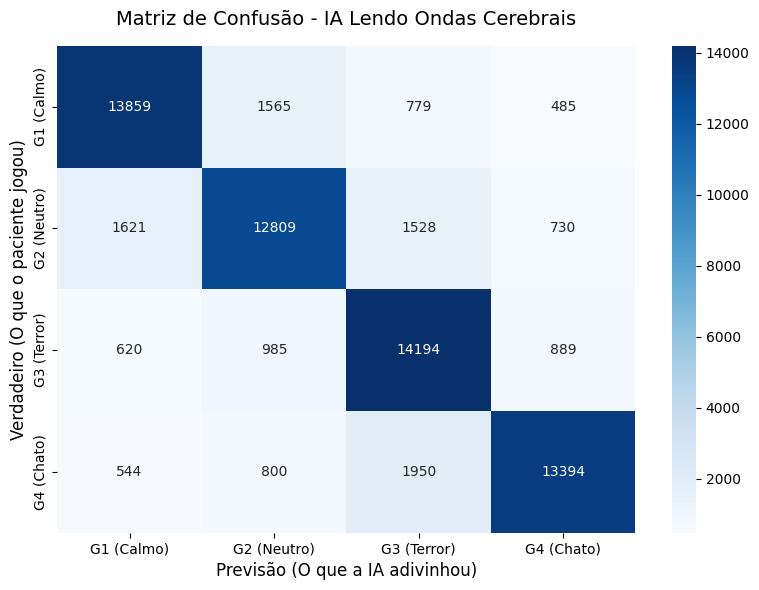

              precision    recall  f1-score   support

  G1 (Calmo)       0.83      0.83      0.83     16688
 G2 (Neutro)       0.79      0.77      0.78     16688
 G3 (Terror)       0.77      0.85      0.81     16688
  G4 (Chato)       0.86      0.80      0.83     16688

    accuracy                           0.81     66752
   macro avg       0.81      0.81      0.81     66752
weighted avg       0.81      0.81      0.81     66752



In [7]:
#classe para definir a arquitetura da CNN
class EmotionCNN(nn.Module): 
    def __init__(self):
        super(EmotionCNN,self).__init__()

        self.conv1 = nn.Conv1d(in_channels=14,out_channels=32,kernel_size=5,padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features=64*32, out_features=128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(in_features=128, out_features=4)

    def forward(self,x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x
    
def treino_cnn(dataset,num_epochs=15,batch_size=64,n_splits=5):
    logo = GroupKFold(n_splits=n_splits)
    acuracias=[]
    todos_gabaritos = []
    todos_chutes = []

    dummy_X = np.zeros(len(dataset))
    rodada = 1
    for train_index, test_index in logo.split(dummy_X, dataset.Y_tensor.numpy(),dataset.groups):
        sujeitos_teste = np.unique(dataset.groups[test_index])
        print(f"\n--- Rodada {rodada:02d} | Testando nos sujeitos: {sujeitos_teste} ---")

        train_subset = Subset(dataset,train_index)
        test_subset = Subset(dataset,test_index)

        train_loader = DataLoader(train_subset,batch_size=batch_size,shuffle=True)
        test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

        modelo = EmotionCNN().to(device)
        criterio = nn.CrossEntropyLoss()
        otimizador = optim.Adam(modelo.parameters(),lr=0.001)

        for epoch in range(num_epochs):
            modelo.train()
            loss_acumulado = 0.0

            for X_batch,Y_batch in train_loader:
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

                otimizador.zero_grad()
                previsoes = modelo(X_batch)
                loss = criterio(previsoes,Y_batch)
                loss.backward()
                otimizador.step()

                loss_acumulado+=loss.item()
                print(f"Época {epoch+1}/{num_epochs} | Loss: {loss_acumulado/len(train_loader):.4f}")

        modelo.eval()
        acertos =0
        total =0
        with torch.no_grad():
            for X_batch, Y_batch in test_loader:
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                previsoes = modelo(X_batch)

                _,chutado = torch.max(previsoes,1)
                total += Y_batch.size(0)
                acertos += (chutado == Y_batch).sum().item() 

                todos_gabaritos.extend(Y_batch.cpu().numpy())
                todos_chutes.extend(chutado.cpu().numpy())

        acuracia = acertos / total
        acuracias.append(acuracia)
        print(f"🎯 Acurácia da Rodada {rodada}: {acuracia:.2%}")
        rodada+=1

    acuracia_media = np.mean(acuracias)
    print("-" * 40)
    print(f"🏆 ACURÁCIA MÉDIA FINAL DA CNN: {acuracia_media:.2%}")
    return  modelo, acuracia_media, todos_gabaritos, todos_chutes


def plot_matriz_confusao(gabaritos, chutes):
    print("\n📊 Gerando Matriz de Confusão...")
    
    jogos = ["G1 (Calmo)", "G2 (Neutro)", "G3 (Terror)", "G4 (Chato)"]
    
    cm = confusion_matrix(gabaritos, chutes)
    
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=jogos, yticklabels=jogos)
    
    plt.title("Matriz de Confusão - IA Lendo Ondas Cerebrais", fontsize=14, pad=15)
    plt.ylabel('Verdadeiro (O que o paciente jogou)', fontsize=12)
    plt.xlabel('Previsão (O que a IA adivinhou)', fontsize=12)
    
    # Exibe na tela
    plt.tight_layout()
    plt.show()

    jogos = ["G1 (Calmo)", "G2 (Neutro)", "G3 (Terror)", "G4 (Chato)"]
    print(classification_report(gabaritos, chutes, target_names=jogos))

if __name__ == "__main__":
    pasta_tensores = pasta_final_numpy
    
    dataset_completo = EEGDataset(pasta_tensores)
    
    modelo, acuracia_cnn, gabaritos, chutes = treino_cnn(dataset_completo, num_epochs=15, batch_size=64, n_splits=5)
    plot_matriz_confusao(gabaritos, chutes)